### Combining pharm stats for England and Spain

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.dates import date2num
import pandas as pd

In [3]:
dfe = pd.read_csv('./data/EDA_England_pharm.csv')
dfs = pd.read_csv('./data/EDA_Spain_pharm.csv')

In [4]:
# summing chemical_substance column for group (antidepressants and anxiolytics) per month
dfe_clean = dfe.groupby(['date', 'country', 'group'], as_index=False).agg(items=('items', 'sum'))
print(dfe_clean.tail(2))
print(dfs.head(2))

        date  country            group      items
118  2025-12  England  Antidepressants  8366599.0
119  2025-12  England      Anxiolytics  2216274.0
      date country            group      items
0  2021-01   Spain      Anxiolytics  4802610.0
1  2021-01   Spain  Antidepressants  3892410.0


In [5]:
# concating two tables
df_pharm_all = pd.concat([dfe_clean, dfs])
df_pharm_all = df_pharm_all.sort_values(['date', 'country', 'group']).reset_index(drop=True)
df_pharm_all.head(4)


,date,country,group,items
0,2021-01,England,Antidepressants,6677221.0
1,2021-01,England,Anxiolytics,1959228.0
2,2021-01,Spain,Antidepressants,3892410.0
3,2021-01,Spain,Anxiolytics,4802610.0


### Joining Population stats to Pharm stats

In [6]:
pop = pd.read_csv('./data/All_population_monthly.csv')
pop.tail(2)

,date,population,country
118,2025-11,49128297,Spain
119,2025-12,49128297,Spain


In [7]:
# joining tables based on date and country
df_pharm_pop = df_pharm_all.merge(pop, on=['date', 'country'], how='left')
df_pharm_pop.head(4)

,date,country,group,items,population
0,2021-01,England,Antidepressants,6677221.0,56489800
1,2021-01,England,Anxiolytics,1959228.0,56489800
2,2021-01,Spain,Antidepressants,3892410.0,47400798
3,2021-01,Spain,Anxiolytics,4802610.0,47400798


In [8]:
# ensure datetime to avoid wrong calculations 
df_pharm_pop['date'] = pd.to_datetime(df_pharm_pop['date'])

# normalize per 1000 people
df_pharm_pop['items_per_1k_norm'] = round((df_pharm_pop['items'] / df_pharm_pop['population'] * 1000 / df_pharm_pop['date'].dt.days_in_month * 30),2)
df_pharm_pop

,date,country,group,items,population,items_per_1k_norm
0,2021-01-01,England,Antidepressants,6677221.0,56489800,114.39
1,2021-01-01,England,Anxiolytics,1959228.0,56489800,33.56
2,2021-01-01,Spain,Antidepressants,3892410.0,47400798,79.47
3,2021-01-01,Spain,Anxiolytics,4802610.0,47400798,98.05
4,2021-02-01,England,Antidepressants,6305584.0,56541183,119.49
...,...,...,...,...,...,...
235,2025-11-01,Spain,Anxiolytics,4157130.0,49128297,84.62
236,2025-12-01,England,Antidepressants,8366599.0,59527325,136.02
237,2025-12-01,England,Anxiolytics,2216274.0,59527325,36.03
238,2025-12-01,Spain,Antidepressants,5213790.0,49128297,102.70


### First visualisation
Monthly prescription rates of antidepressants and anxiolytics in England and Spain (2021–2025), including linear trend lines to illustrate long-term prescribing patterns over time.

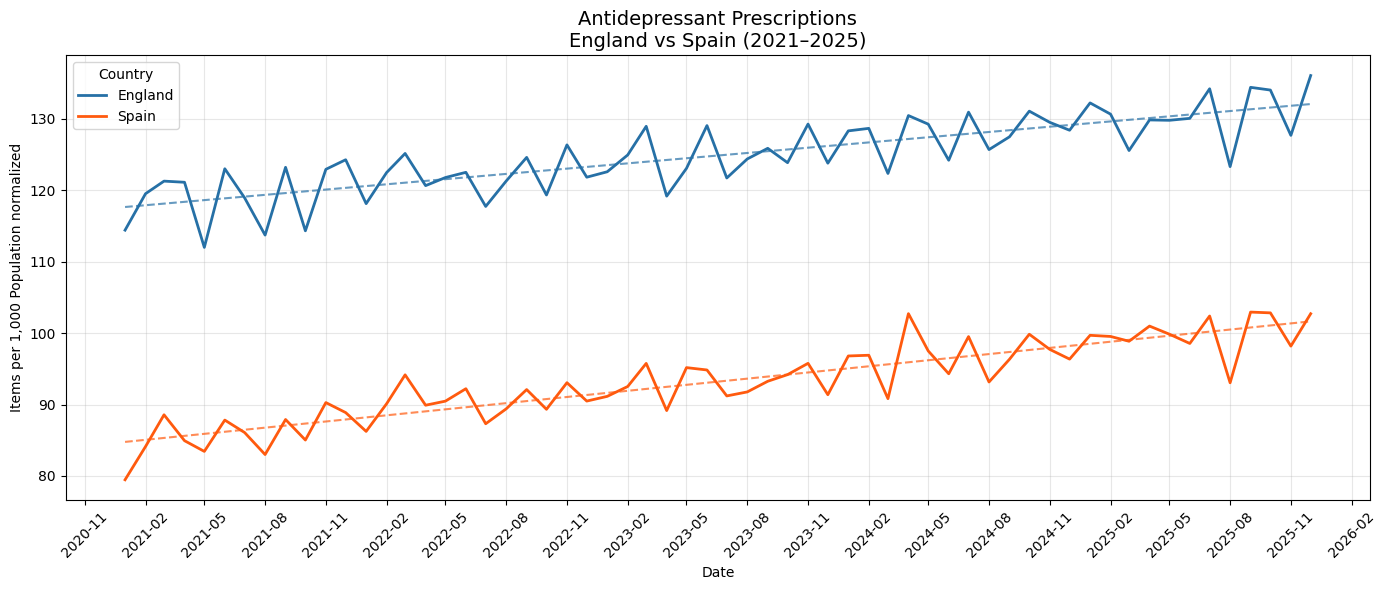

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(
    ['England', 'Spain'],
    ["#2670A6", "#ff5a0e"]
):
    df_c = df_pharm_pop[
        (df_pharm_pop['country'] == country) &
        (df_pharm_pop['group'] == 'Antidepressants')
    ].sort_values('date')
    # Main line
    ax.plot(
        df_c['date'],
        df_c['items_per_1k_norm'],
        label=country,
        color=color,
        linewidth=2
    )
    # Trend line
    x_num = date2num(df_c['date'].values)

    z = np.polyfit(
        x_num,
        df_c['items_per_1k_norm'],
        1
    )
    p = np.poly1d(z)
    ax.plot(df_c['date'],
            p(x_num),
            color=color,
            linestyle='--',
            linewidth=1.5,
            alpha=0.7)
ax.set_title(
    'Antidepressant Prescriptions\nEngland vs Spain (2021–2025)',
    fontsize=14
)
ax.set_xlabel('Date')
ax.set_ylabel('Items per 1,000 Population normalized')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend(title='Country')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import plotly.graph_objects as go
from scipy import stats
import numpy as np

fig = go.Figure()

for country, color in zip(['England', 'Spain'], ["#2670A6", "#ff5a0e"]):
    df_c = df_pharm_pop[
        (df_pharm_pop['country'] == country) &
        (df_pharm_pop['group'] == 'Antidepressants')
    ].sort_values('date')
    
    # Main line
    fig.add_trace(go.Scatter(
        x=df_c['date'],
        y=df_c['items_per_1k_norm'],
        name=country,
        line=dict(color=color, width=2),
        mode='lines'
    ))
    
    # Statistical trend line (OLS regression)
    x_num = np.arange(len(df_c))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_num, df_c['items_per_1k_norm'])
    trend = intercept + slope * x_num
    
    fig.add_trace(go.Scatter(
        x=df_c['date'],
        y=trend,
        name=f'{country} trend (R²={r_value**2:.3f})',
        line=dict(color=color, width=1.5, dash='dash'),
        mode='lines',
        opacity=0.7
    ))

fig.update_layout(
    title='Antidepressant Prescriptions<br>England vs Spain (2021–2025)',
    xaxis_title='Date',
    yaxis_title='Items per 1,000 Population (normalized)',
    legend_title='Country',
    hovermode='x unified',
    template='plotly_white',
    width=1100,
    height=500
)

fig.show()

In [11]:
# Check if February is consistently lower
for country in ['England', 'Spain']:
    df_c = df_pharm_pop[
        (df_pharm_pop['country'] == country) &
        (df_pharm_pop['group'] == 'Antidepressants')
    ].copy()
    df_c['month'] = pd.to_datetime(df_c['date']).dt.month
    
    print(f"\n{country} - Average by month:")
    print(df_c.groupby('month')['items_per_1k_norm'].mean().round(2))


England - Average by month:
month
1     123.10
2     125.22
3     124.63
4     124.22
5     123.15
6     125.74
7     124.68
8     121.65
9     127.08
10    124.49
11    127.11
12    126.84
Name: items_per_1k_norm, dtype: float64

Spain - Average by month:
month
1     90.66
2     92.63
3     93.63
4     93.53
5     93.28
6     93.54
7     93.29
8     90.07
9     94.50
10    94.24
11    94.99
12    93.95
Name: items_per_1k_norm, dtype: float64


In [12]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [13]:
import holidays
import calendar

def count_working_days(year, month, country):
    if country == 'England':
        country_holidays = holidays.country_holidays('GB', subdiv='ENG', years=year)
    else:
        country_holidays = holidays.country_holidays('ES', years=year)
    
    _, days_in_month = calendar.monthrange(year, month)
    
    working_days = 0
    for day in range(1, days_in_month + 1):
        date = pd.Timestamp(year=year, month=month, day=day)
        if date.weekday() < 5 and date not in country_holidays:
            working_days += 1
    
    return working_days

# Add year and month columns
df_pharm_pop['year'] = pd.to_datetime(df_pharm_pop['date']).dt.year
df_pharm_pop['month'] = pd.to_datetime(df_pharm_pop['date']).dt.month

# Count working days per month per country
df_pharm_pop['working_days'] = df_pharm_pop.apply(
    lambda row: count_working_days(row['year'], row['month'], row['country']), axis=1
)

# Average working days across all months and countries
avg_working_days = df_pharm_pop['working_days'].mean().round(0)
print(f'Average working days: {avg_working_days}')

# Normalize by working days scaled to average
df_pharm_pop['items_per_workday_1k'] = (
    df_pharm_pop['items'] / df_pharm_pop['population'] * 1000 
    / df_pharm_pop['working_days'] * avg_working_days
).round(2)

# Check results
print(df_pharm_pop[['date', 'country', 'group', 'working_days', 
                      'items_per_1k_norm', 'items_per_workday_1k']].head(10))

Average working days: 21.0
        date  country            group  working_days  items_per_1k_norm  \
0 2021-01-01  England  Antidepressants            20             114.39   
1 2021-01-01  England      Anxiolytics            20              33.56   
2 2021-01-01    Spain  Antidepressants            19              79.47   
3 2021-01-01    Spain      Anxiolytics            19              98.05   
4 2021-02-01  England  Antidepressants            20             119.49   
5 2021-02-01  England      Anxiolytics            20              35.16   
6 2021-02-01    Spain  Antidepressants            20              84.12   
7 2021-02-01    Spain      Anxiolytics            20             104.45   
8 2021-03-01  England  Antidepressants            23             121.25   
9 2021-03-01  England      Anxiolytics            23              35.43   

   items_per_workday_1k  
0                124.11  
1                 36.42  
2                 90.76  
3                111.98  
4                

In [14]:
for country in ['England', 'Spain']:
    df_c = df_pharm_pop[
        (df_pharm_pop['country'] == country) &
        (df_pharm_pop['group'] == 'Antidepressants')
    ]
    print(f"\n{country} - Average by month (working days adjusted):")
    print(df_c.groupby('month')['items_per_workday_1k'].mean().round(2))


England - Average by month (working days adjusted):
month
1     127.16
2     122.37
3     123.30
4     133.24
5     132.30
6     125.91
7     122.95
8     124.67
9     124.74
10    122.72
11    124.95
12    136.34
Name: items_per_workday_1k, dtype: float64

Spain - Average by month (working days adjusted):
month
1      95.40
2      90.52
3      92.68
4      95.38
5      93.73
6      91.99
7      91.97
8      91.55
9      91.93
10     95.54
11     96.95
12    102.17
Name: items_per_workday_1k, dtype: float64


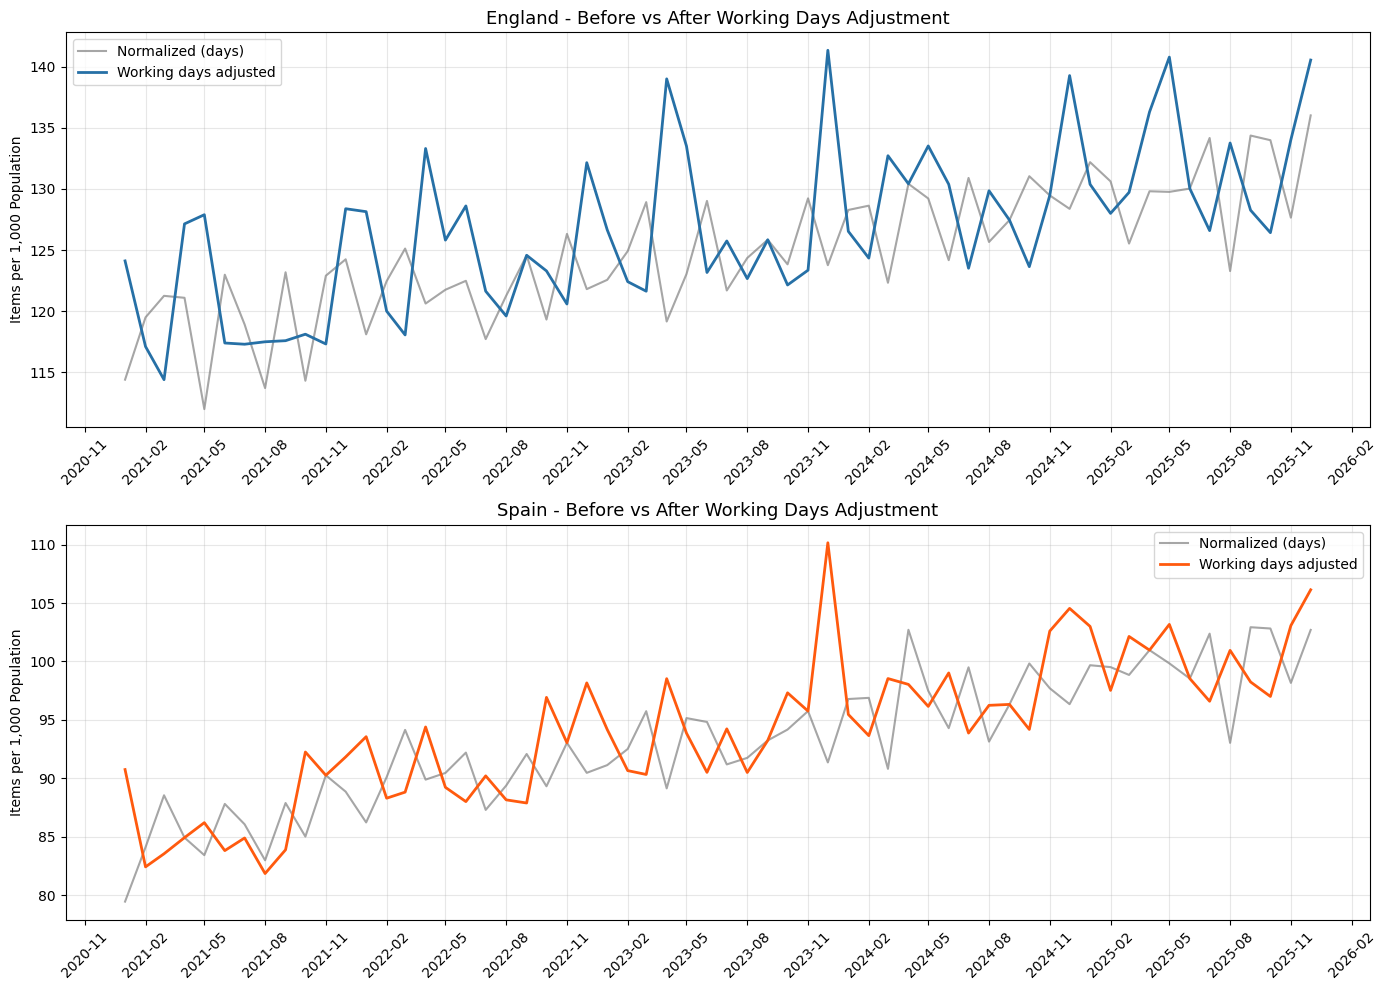

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, country in enumerate(['England', 'Spain']):
    ax = axes[idx]
    
    df_c = df_pharm_pop[
        (df_pharm_pop['country'] == country) &
        (df_pharm_pop['group'] == 'Antidepressants')
    ].sort_values('date').copy()
    
    df_c['date'] = pd.to_datetime(df_c['date'])
    
    # Plot both lines
    ax.plot(df_c['date'], df_c['items_per_1k_norm'],
            label='Normalized (days)', color='grey',
            linewidth=1.5, alpha=0.7)
    
    ax.plot(df_c['date'], df_c['items_per_workday_1k'],
            label='Working days adjusted', 
            color='#2670A6' if country == 'England' else '#ff5a0e',
            linewidth=2)
    
    ax.set_title(f'{country} - Before vs After Working Days Adjustment', fontsize=13)
    ax.set_ylabel('Items per 1,000 Population')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

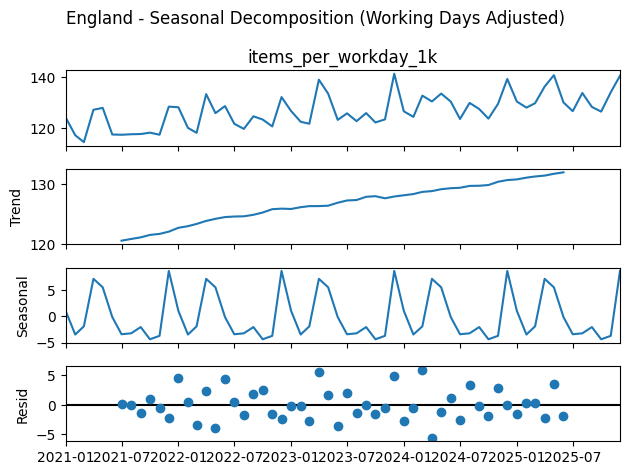

England - p-value: 0.0000 ✅ Seasonal


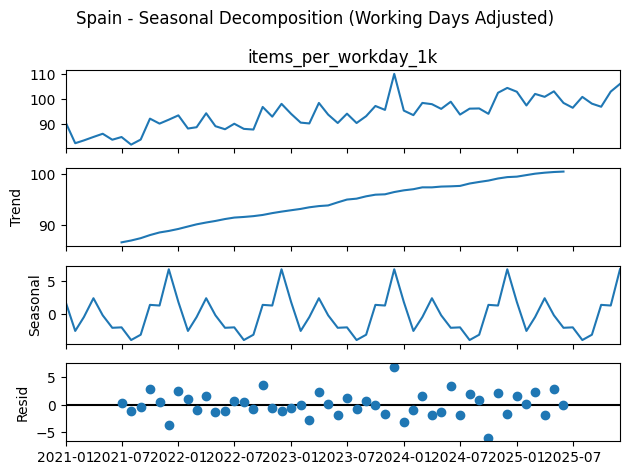

Spain - p-value: 0.0000 ✅ Seasonal


In [16]:
from scipy.stats import kruskal
from statsmodels.tsa.seasonal import seasonal_decompose

for country in ['England', 'Spain']:
    df_c = df_pharm_pop[
        (df_pharm_pop['country'] == country) &
        (df_pharm_pop['group'] == 'Antidepressants')
    ].sort_values('date').copy()
    
    df_c['date'] = pd.to_datetime(df_c['date'])
    
    # Decomposition
    decomp = seasonal_decompose(
        df_c.set_index('date')['items_per_workday_1k'], 
        model='additive', period=12
    )
    decomp.plot()
    plt.suptitle(f'{country} - Seasonal Decomposition (Working Days Adjusted)')
    plt.tight_layout()
    plt.show()
    
    # Kruskal-Wallis on seasonal component
    df_c['detrended'] = decomp.seasonal.values
    df_c['month'] = df_c['date'].dt.month
    groups = [df_c[df_c['month'] == m]['detrended'] for m in range(1, 13)]
    stat, p_value = kruskal(*groups)
    print(f'{country} - p-value: {p_value:.4f}', '✅ Seasonal' if p_value < 0.05 else '❌ No seasonality')

In [17]:
df_england = df_pharm_pop[
    (df_pharm_pop['country'] == 'England') &
    (df_pharm_pop['group'] == 'Antidepressants')
].copy()

df_england['month'] = pd.to_datetime(df_england['date']).dt.month
df_england['season'] = df_england['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

print(df_england.groupby('season')['items_per_workday_1k'].mean().round(2).sort_values(ascending=False))

# Test if summer is significantly different from other seasons
from scipy.stats import mannwhitneyu

summer = df_england[df_england['season'] == 'Summer']['items_per_workday_1k']
non_summer = df_england[df_england['season'] != 'Summer']['items_per_workday_1k']

stat, p_value = mannwhitneyu(summer, non_summer)
print(f'\nSummer vs rest - p-value: {p_value:.4f}', '✅ Significant' if p_value < 0.05 else '❌ Not significant')

season
Spring    129.61
Winter    128.62
Summer    124.51
Autumn    124.14
Name: items_per_workday_1k, dtype: float64

Summer vs rest - p-value: 0.1667 ❌ Not significant


In [18]:
from scipy.stats import kruskal
from statsmodels.tsa.seasonal import seasonal_decompose

for country in ['England', 'Spain']:
    df_c = df_pharm_pop[
        (df_pharm_pop['country'] == country) &
        (df_pharm_pop['group'] == 'Antidepressants')
    ].sort_values('date').copy()
    
    df_c['date'] = pd.to_datetime(df_c['date'])
    
    # Remove trend first
    decomp = seasonal_decompose(df_c.set_index('date')['items_per_1k_norm'], 
                                model='additive', period=12)
    df_c['detrended'] = decomp.seasonal.values
    
    df_c['month'] = df_c['date'].dt.month
    groups = [df_c[df_c['month'] == m]['detrended'] for m in range(1, 13)]
    stat, p_value = kruskal(*groups)
    print(f'{country} - p-value: {p_value:.4f}', '✅ Seasonal' if p_value < 0.05 else '❌ No seasonality')

England - p-value: 0.0000 ✅ Seasonal
Spain - p-value: 0.0000 ✅ Seasonal


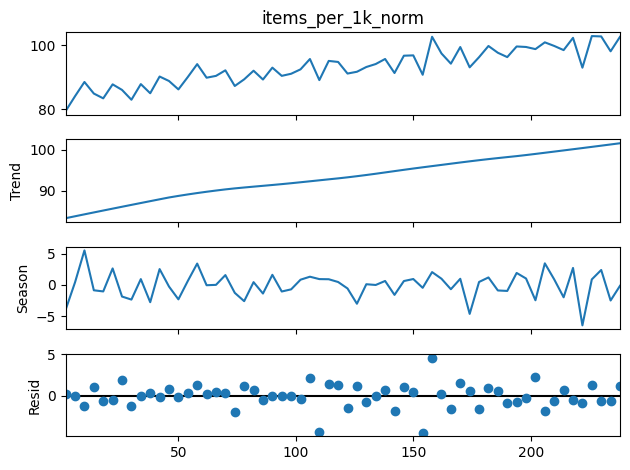

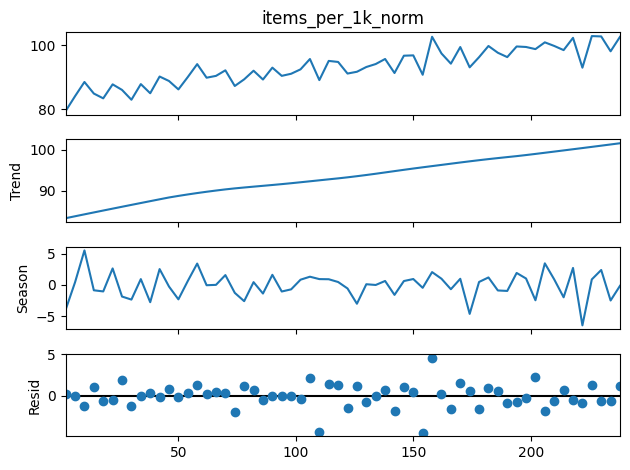

In [19]:
from statsmodels.tsa.seasonal import STL
stl = STL(df_c['items_per_1k_norm'], period=12)
result = stl.fit()
result.plot()

In [20]:
df_pharm_pop.to_csv("Master_table_Spain_England.csv", index=False)

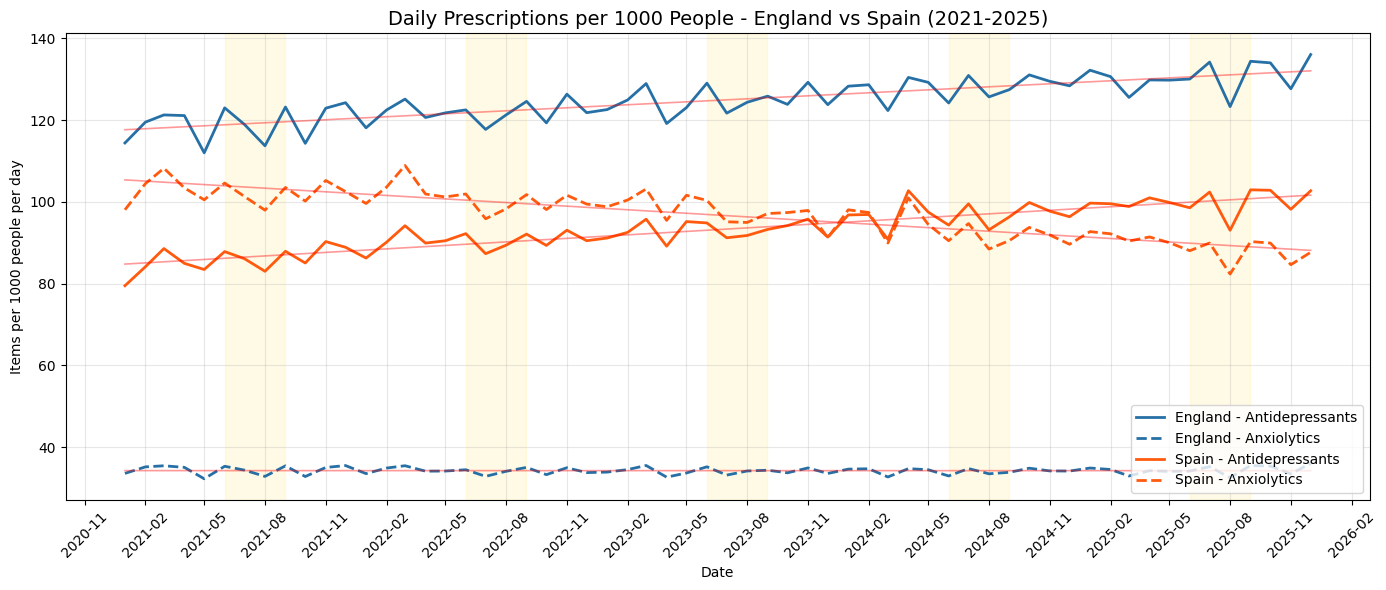

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Adding shadowing for summer
years = range(2021, 2026)
for year in years:
    summer_start = pd.Timestamp(f'{year}-06-01')
    summer_end = pd.Timestamp(f'{year}-08-31')
    ax.axvspan(
        summer_start,
        summer_end,
        alpha=0.1,
        color='gold')
    
#  Plot lines
for country, color in zip(
    ['England', 'Spain'],
    ["#2670A6", "#ff5a0e"]
):
    for group, linestyle in zip(
        ['Antidepressants', 'Anxiolytics'],
        ['-', '--']
    ):
        df_c = df_pharm_pop[
            (df_pharm_pop['country'] == country) &
            (df_pharm_pop['group'] == group)
        ].sort_values('date')
        # main line
        ax.plot(
            df_c['date'],
            df_c['items_per_1k_norm'],
            label=f'{country} - {group}',
            color=color,
            linestyle=linestyle,
            linewidth=2
        )
        # trend line
        x_num = date2num(df_c['date'].values)
        z = np.polyfit(
            x_num,
            df_c['items_per_1k_norm'],
            1
        )
        p = np.poly1d(z)
        ax.plot(
            df_c['date'],
            p(x_num),
            color='red',
            linestyle='-',
            linewidth=1.2,
            alpha=0.4
        )
ax.set_title(
    'Daily Prescriptions per 1000 People - England vs Spain (2021-2025)',
    fontsize=14
)
ax.set_xlabel('Date')
ax.set_ylabel('Items per 1000 people per day')
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)
plt.xticks(rotation=45)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## __Joining weather data__

In [22]:
df_w = pd.read_csv('./data/all_weather_clean.csv')
df_w.head(2)

,date,tavg,tmin,tmax,prcp,pres,tsun,station_name
0,2023-07,15.9,13.2,18.5,NaN,1006.9,8138.0,Sunderland
1,2024-01,5.3,3.6,7.1,NaN,1013.2,3962.0,Sunderland


In [23]:
# checking distinct cities to group
df_w['station_name'].unique()

<ArrowStringArray>
[            'Sunderland',    'Newcastle upon Tyne',                  'Leeds',
                'Bristol',                 'London',          'Middlesbrough',
             'Manchester',                   'York',             'Nottingham',
           'Peterborough',             'Birmingham',               'Plymouth',
                 'Exeter',               'Brighton',             'Canterbury',
                 'Bilbao', 'Santiago de Compostela',               'Valencia',
              'Barcelona',                'Seville',                 'Malaga',
                 'Madrid',               'Zaragoza']
Length: 23, dtype: str

In [24]:
# Creating lists of cities for England and Spain 
england_cities = [
    'Sunderland', 'Newcastle upon Tyne', 'Leeds', 'Bristol', 'London',
    'Middlesbrough', 'Manchester', 'York', 'Nottingham', 'Peterborough',
    'Birmingham', 'Plymouth', 'Exeter', 'Brighton', 'Canterbury'
]
spain_cities = [
    'Bilbao', 'Santiago de Compostela', 'Valencia', 'Barcelona',
    'Seville', 'Malaga', 'Madrid', 'Zaragoza'
]
# Add country column
df_w['country'] = df_w['station_name'].apply(
    lambda x: 'England' if x in england_cities else ('Spain' if x in spain_cities else 'Unknown')
)
# Calculate mean, median and std per month per country 

df_weather_agg = df_w.groupby(['date', 'country']).agg(
    tavg_mean=('tavg', 'mean'),
    tavg_std=('tavg', 'std'),
    tmin_mean=('tmin', 'mean'),
    tmin_std=('tmin', 'std'),
    tmax_mean=('tmax', 'mean'),
    tmax_std=('tmax', 'std'),
    prcp_mean=('prcp', 'mean'),
    prcp_std=('prcp', 'std'),
    pres_mean=('pres', 'mean'),
    pres_std=('pres', 'std'),
    tsun_mean=('tsun', 'mean'),
    tsun_std=('tsun', 'std')
).round(1).reset_index()

df_weather_agg.head()

,date,country,tavg_mean,tavg_std,tmin_mean,tmin_std,tmax_mean,tmax_std,prcp_mean,prcp_std,pres_mean,pres_std,tsun_mean,tsun_std
0,2021-01,England,3.5,1.2,1.2,1.2,5.6,1.2,98.1,33.5,1010.6,0.9,3139.6,1011.8
1,2021-01,Spain,8.5,2.7,4.1,2.8,12.8,3.0,97.1,71.9,1017.8,1.8,8581.9,3109.1
2,2021-02,England,5.2,0.8,2.6,0.9,7.7,0.9,65.2,22.2,1013.9,1.0,3926.1,680.2
3,2021-02,Spain,12.4,1.9,8.1,2.1,16.7,1.9,69.5,96.6,1017.9,1.4,7773.8,1835.5
4,2021-03,England,7.2,0.5,3.9,0.6,10.5,0.6,54.0,33.4,1020.6,1.8,6518.8,1451.7


I have a pretty significant standard deviation in the weather data because of outliers.

In [25]:
df_w[df_w['date'] == '2021-01'][['station_name', 'tsun']].sort_values('station_name').head()

,station_name,tsun
1029,Barcelona,7635.0
849,Bilbao,2640.0
282,Birmingham,4042.0
843,Brighton,1770.0
805,Bristol,1764.0


### First visualisation of sun hours 

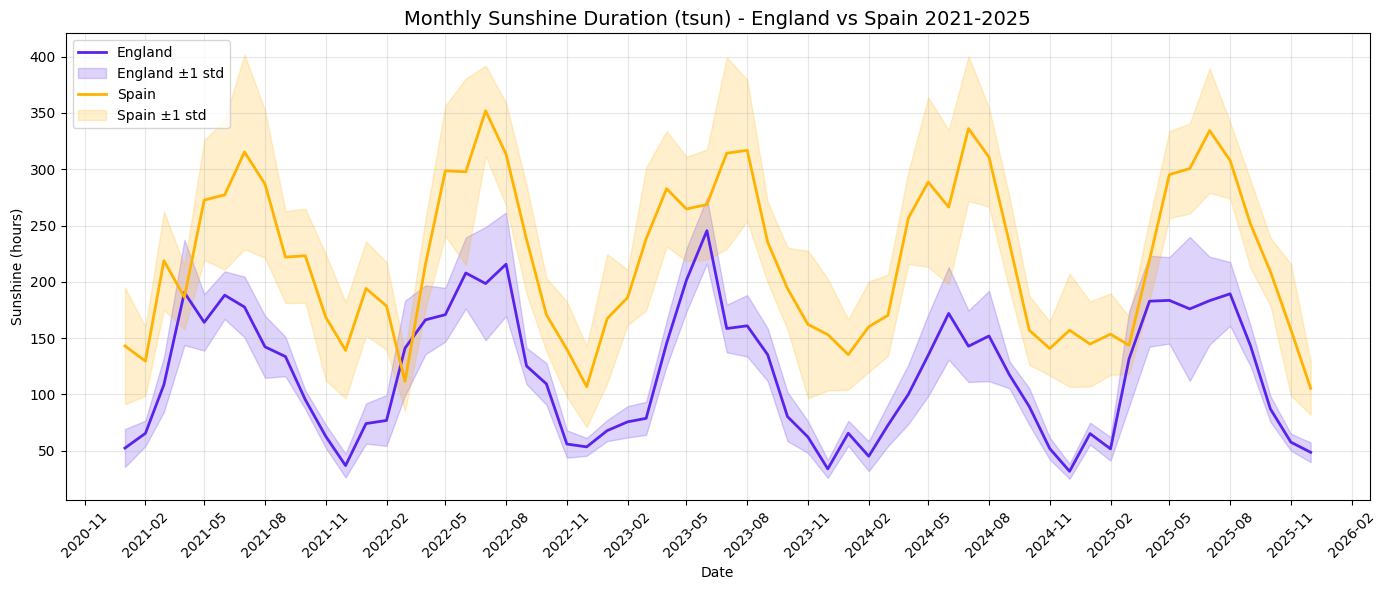

In [26]:
# Convert date to datetime for proper x-axis
df_weather_agg['date'] = pd.to_datetime(df_weather_agg['date'])

# convert minutes to hours
df_weather_agg['tsun_mean_hours'] = df_weather_agg['tsun_mean'] / 60
df_weather_agg['tsun_std_hours'] = df_weather_agg['tsun_std'] / 60

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(['England', 'Spain'], ["#5923ed", "#ffb300"]):
    df_c = df_weather_agg[df_weather_agg['country'] == country].sort_values('date')
    
    # Line
    ax.plot(
        df_c['date'],
        df_c['tsun_mean_hours'],
        label=country,
        color=color,
        linewidth=2
    )
    
    # Std band
    ax.fill_between(
        df_c['date'],
        df_c['tsun_mean_hours'] - df_c['tsun_std_hours'],
        df_c['tsun_mean_hours'] + df_c['tsun_std_hours'],
        alpha=0.2,
        color=color,
        label=f'{country} ±1 std'
    )

ax.set_title(
    'Monthly Sunshine Duration (tsun) - England vs Spain 2021-2025',
    fontsize=14
)

ax.set_xlabel('Date')
ax.set_ylabel('Sunshine (hours)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

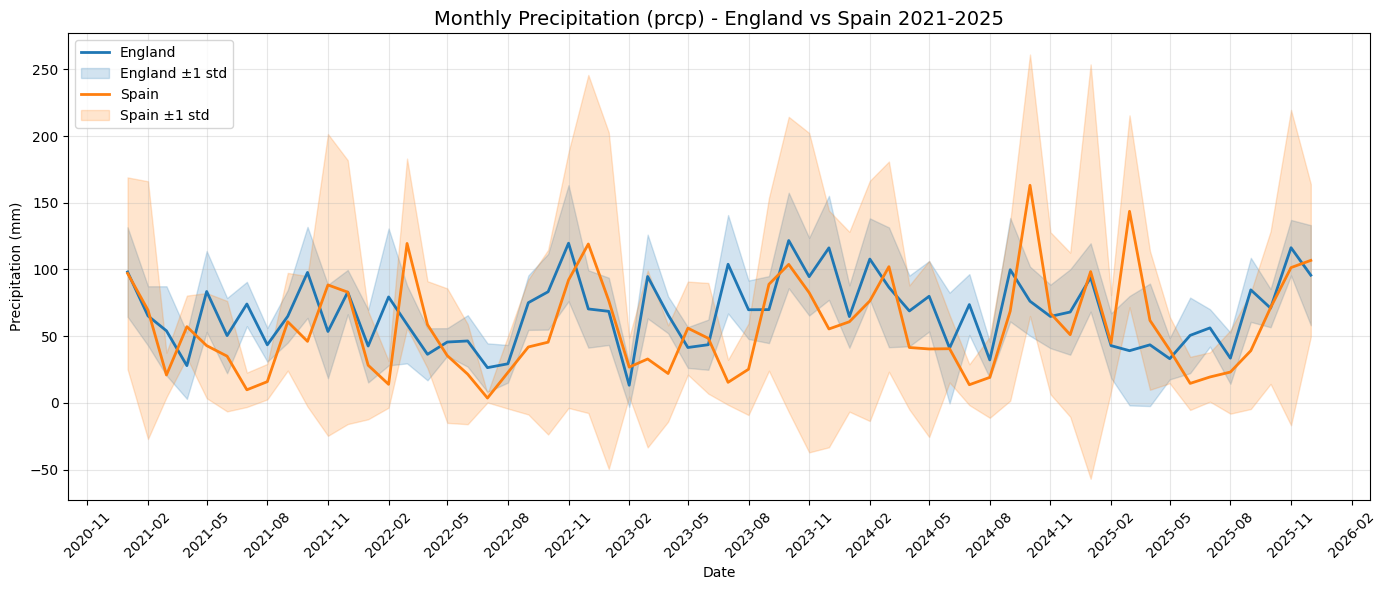

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(['England', 'Spain'], ['#1f77b4', '#ff7f0e']):
    df_c = df_weather_agg[df_weather_agg['country'] == country].sort_values('date')
    
    ax.plot(df_c['date'], df_c['prcp_mean'], label=country, color=color, linewidth=2)
    
    ax.fill_between(
        df_c['date'],
        df_c['prcp_mean'] - df_c['prcp_std'],
        df_c['prcp_mean'] + df_c['prcp_std'],
        alpha=0.2,
        color=color,
        label=f'{country} ±1 std'
    )

ax.set_title('Monthly Precipitation (prcp) - England vs Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
england_cities = [
    'Sunderland', 'Newcastle upon Tyne', 'Leeds', 'Bristol', 'London',
    'Middlesbrough', 'Manchester', 'York', 'Nottingham', 'Peterborough',
    'Birmingham', 'Plymouth', 'Exeter', 'Brighton', 'Canterbury'
]

spain_cities = [
    'Bilbao', 'Santiago de Compostela', 'Valencia', 'Barcelona',
    'Seville', 'Malaga', 'Madrid', 'Zaragoza'
]

# Add country column
df_w['country'] = df_w['station_name'].apply(
    lambda x: 'England' if x in england_cities else ('Spain' if x in spain_cities else 'Unknown')
)

# Calculate average and std per month per country
df_weather_agg_mean_median = df_w.groupby(['date', 'country']).agg(
    tavg_mean=('tavg', 'mean'),
    tavg_median=('tavg', 'median'),
    tavg_std=('tavg', 'std'),
    tmin_mean=('tmin', 'mean'),
    tmin_median=('tmin', 'median'),
    tmin_std=('tmin', 'std'),
    tmax_mean=('tmax', 'mean'),
    tmax_median=('tmax', 'median'),
    tmax_std=('tmax', 'std'),
    prcp_mean=('prcp', 'mean'),
    prcp_median=('prcp', 'median'),
    prcp_std=('prcp', 'std'),
    tsun_mean=('tsun', 'mean'),
    tsun_median=('tsun', 'median'),
    tsun_std=('tsun', 'std')
).round(1).reset_index()


df_weather_agg_mean_median.head(4)

,date,country,tavg_mean,tavg_median,tavg_std,tmin_mean,tmin_median,tmin_std,tmax_mean,tmax_median,tmax_std,prcp_mean,prcp_median,prcp_std,tsun_mean,tsun_median,tsun_std
0,2021-01,England,3.5,3.1,1.2,1.2,0.8,1.2,5.6,5.3,1.2,98.1,93.5,33.5,3139.6,3468.0,1011.8
1,2021-01,Spain,8.5,8.7,2.7,4.1,4.6,2.8,12.8,12.6,3.0,97.1,68.0,71.9,8581.9,9510.0,3109.1
2,2021-02,England,5.2,4.9,0.8,2.6,2.5,0.9,7.7,7.8,0.9,65.2,62.5,22.2,3926.1,3936.0,680.2
3,2021-02,Spain,12.4,12.8,1.9,8.1,9.0,2.1,16.7,16.7,1.9,69.5,34.0,96.6,7773.8,8400.0,1835.5


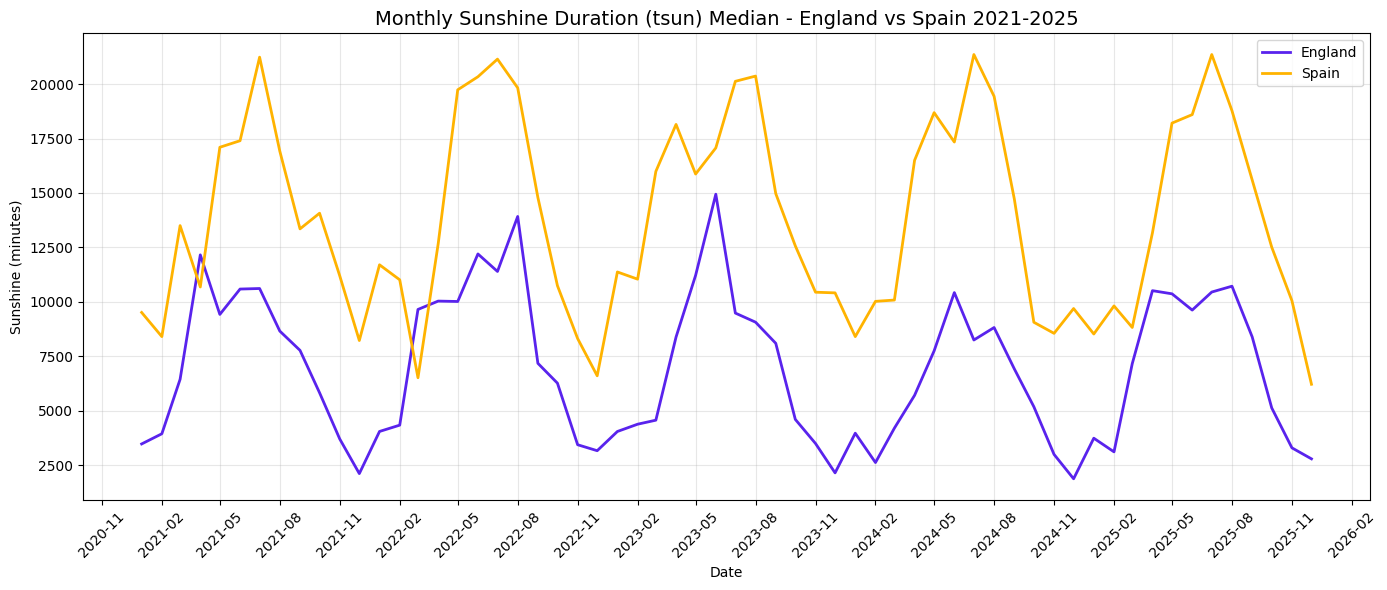

In [29]:
df_weather_agg_mean_median['date'] = pd.to_datetime(df_weather_agg_mean_median['date'])

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(['England', 'Spain'], ["#5923ed", "#ffb300"]):
    df_c = df_weather_agg_mean_median[df_weather_agg_mean_median['country'] == country].sort_values('date')
    
    ax.plot(df_c['date'], df_c['tsun_median'], label=country, color=color, linewidth=2)

ax.set_title('Monthly Sunshine Duration (tsun) Median - England vs Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sunshine (minutes)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
df_all = df_pharm_pop.merge(df_weather_agg_mean_median, on=['date', 'country'], how='left')

In [31]:
df_all.head(2)

,date,country,group,items,population,items_per_1k_norm,year,month,working_days,items_per_workday_1k,...,tmin_std,tmax_mean,tmax_median,tmax_std,prcp_mean,prcp_median,prcp_std,tsun_mean,tsun_median,tsun_std
0,2021-01-01,England,Antidepressants,6677221.0,56489800,114.39,2021,1,20,124.11,...,1.2,5.6,5.3,1.2,98.1,93.5,33.5,3139.6,3468.0,1011.8
1,2021-01-01,England,Anxiolytics,1959228.0,56489800,33.56,2021,1,20,36.42,...,1.2,5.6,5.3,1.2,98.1,93.5,33.5,3139.6,3468.0,1011.8


In [32]:
df_all.to_csv("Master_table_Spain_England.csv", index=False)

## Checking the correlation between hours of sunshine and antidepressant prescriptions with a one-month lag.


In [1]:
fig, ax = plt.subplots(figsize=(10, 6))

for country, color in zip(['England', 'Spain'], ["#5923ed", "#ffb300"]):
    df_c = df_all[(df_all['country'] == country) & 
                  (df_all['group'] == 'Antidepressants')].sort_values('date').copy()
    
    # Shift prescriptions by 1 month (lag)
    df_c['items_per_1k_lagged'] = df_c['items_per_1k_per_day'].shift(1)
    df_c = df_c.dropna()  # drop first row which becomes NaN
    
    ax.scatter(df_c['tsun_median'], df_c['items_per_1k_per_day'],
               label=country, color=color, alpha=0.6, s=50)
    
    # Trend line
    z = np.polyfit(df_c['tsun_median'], df_c['items_per_1k_per_day'], 1)
    p = np.poly1d(z)
    x_sorted = df_c['tsun_median'].sort_values()
    ax.plot(x_sorted, p(x_sorted), color=color, linewidth=2)

ax.set_xlabel('Sunshine Duration Median (minutes)')
ax.set_ylabel('Antidepressant Items per 1000 population per day')
ax.set_title('Antidepressant Prescriptions (lagged 1 month) vs Sunshine', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined